LIBRARIES

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

INPUTS

In [2]:
IMG_HEIGHT=227
IMG_WIDTH =227
IMG_CHANNELS = 3
CLASS_NAMES = ["lilly", "lotus", "orchid", "sunflower", "tulip"]

In [3]:
train_dataset= tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\train",
    labels ='inferred',
    label_mode = 'int',
    batch_size=16,
    image_size=(IMG_HEIGHT, IMG_WIDTH)
)

val_dataset= tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\val",
    labels ='inferred',
    label_mode = 'int',
    batch_size=16,
    image_size=(IMG_HEIGHT, IMG_WIDTH)
)
normalize = tf.keras.layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalize(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalize(x), y))

Found 3000 files belonging to 5 classes.
Found 1000 files belonging to 5 classes.


NETWORK ARCHITECTURE

In [4]:
def FireModule(squeeze_ch, expand_ch, s):

    squeeze = tf.keras.layers.Conv2D(squeeze_ch, kernel_size=1, activation='relu')(s)

    expand1 = tf.keras.layers.Conv2D(expand_ch, kernel_size=1, activation='relu')(squeeze)
    expand2 = tf.keras.layers.Conv2D(expand_ch, kernel_size=3, padding='same', activation='relu')(squeeze)

    out = tf.keras.layers.Concatenate(axis=-1)([expand1, expand2])

    return out


In [5]:

inputs=keras.layers.Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))

x = keras.layers.Conv2D(filters=96, kernel_size=7, strides=2, padding='same')(inputs)
x = keras.layers.MaxPool2D(pool_size=3, strides=2)(x)

x = FireModule(16, 64, x)
x = FireModule(32, 128, x)

x = keras.layers.MaxPool2D(pool_size=3, strides=2)(x)

x = FireModule(48, 192, x)
x = FireModule(64, 256, x)

x = keras.layers.MaxPool2D(pool_size=3, strides=2)(x)

x = FireModule(64, 256, x)

x = keras.layers.Conv2D(filters=1000, kernel_size=1, strides=1, padding='same')(x)
x = keras.layers.AveragePooling2D(pool_size=13, strides=1)(x)

x= keras.layers.Flatten()(x)

outputs =  keras.layers.Dense(5, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 227, 227,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 114, 114,  │     14,208 │ input_layer[0][0] │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │      1,552 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │      1,088 │ conv2d_1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │      9,280 │ conv2d_1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 56, 56,    │          0 │ conv2d_2[0][0],   │
│ (Concatenate)       │ 128)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │      4,128 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 56, 56,    │      4,224 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 56, 56,    │     36,992 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 56, 56,    │          0 │ conv2d_5[0][0],   │
│ (Concatenate)       │ 256)              │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 27, 27,    │          0 │ concatenate_1[0]… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 27, 27,    │     12,336 │ max_pooling2d_1[… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 27, 27,    │      9,408 │ conv2d_7[0][0]    │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 27, 27,    │     83,136 │ conv2d_7[0][0]    │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 27, 27,    │          0 │ conv2d_8[0][0],   │
│ (Concatenate)       │ 384)              │            │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 27, 27,    │     24,640 │ concatenate_2[0]

 Total params: 1,080,533 (4.12 MB)

 Trainable params: 1,080,533 (4.12 MB)

 Non-trainable params: 0 (0.00 B)

TRAINING

In [6]:
EPOCHS=10
history = model.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 62s 314ms/step - accuracy: 0.1907 - loss: 1.6130 - val_accuracy: 0.2000 - val_loss: 1.6112
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 63s 332ms/step - accuracy: 0.1993 - loss: 1.6115 - val_accuracy: 0.2000 - val_loss: 1.6103
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 63s 333ms/step - accuracy: 0.1990 - loss: 1.6110 - val_accuracy: 0.2000 - val_loss: 1.6099
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 63s 336ms/step - accuracy: 0.2070 - loss: 1.6106 - val_accuracy: 0.2000 - val_loss: 1.6097
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 67s 354ms/step - accuracy: 0.1917 - loss: 1.6102 - val_accuracy: 0.2000 - val_loss: 1.6096
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 64s 339ms/step - accuracy: 0.1920 - loss: 1.6100 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 64s 341ms/step - accuracy: 0.1967 - loss: 1.6100 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 64s 338ms/step - accuracy: 0.2010 - loss: 1

PLOTTING

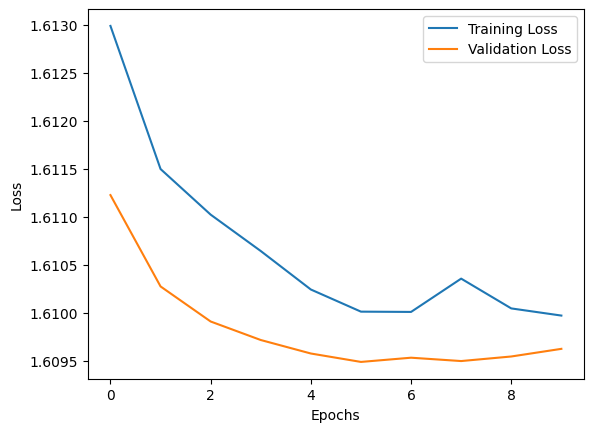

In [7]:
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

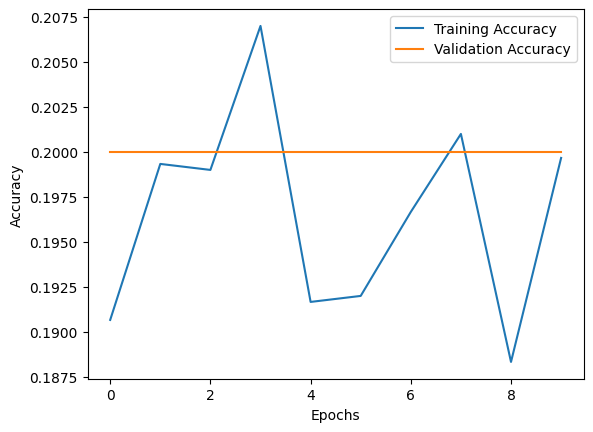

In [8]:
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()